# Fraud Detection — Layer 1
## Notebook 3: Modelling
**Author:** Frederick Amartey-Fio  
**Institution:** JUNIA ISEN — MSc Big Data  
**Date:** May 2026

---

### Objective
Train and compare three models on the preprocessed data:
- **Model 1:** Logistic Regression — simple baseline
- **Model 2:** XGBoost — our primary fraud detection model
- **Model 3:** Isolation Forest — unsupervised anomaly detection

We evaluate using F1-score and AUC-ROC, not accuracy.

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — IMPORTS
# Load all libraries needed for modelling and evaluation.
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report,   # precision, recall, F1 for each class
    roc_auc_score,           # AUC-ROC score
    roc_curve,               # for plotting the ROC curve
    confusion_matrix,        # shows TP, TN, FP, FN
    f1_score                 # single F1 score value
)

%matplotlib inline
sns.set_style("whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — LOAD PREPROCESSED DATA
# Load the saved arrays from Notebook 2.
# No need to redo any preprocessing — everything is ready.
# ─────────────────────────────────────────────────────────────

X_train = joblib.load("../models/X_train_smote.pkl")
y_train = joblib.load("../models/y_train_smote.pkl")
X_test  = joblib.load("../models/X_test.pkl")
y_test  = joblib.load("../models/y_test.pkl")
feature_columns = joblib.load("../models/feature_columns.pkl")

print("Data loaded successfully.")
print()
print(f"Training set : {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} rows, {X_test.shape[1]} features")
print()
print(f"Fraud in test set : {y_test.sum():,} out of {len(y_test):,}")

Data loaded successfully.

Training set : 454,902 rows, 30 features
Test set     : 56,962 rows, 30 features

Fraud in test set : 98 out of 56,962


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — MODEL 1: LOGISTIC REGRESSION (BASELINE)
# The simplest classification model.
# We train it first to set a baseline score.
# Every other model must beat this to be worth using.
# ─────────────────────────────────────────────────────────────

print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,      # enough iterations to converge
    random_state=42
)

lr_model.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]  # fraud probability

# Evaluate
print("Done.\n")
print("─── Logistic Regression Results ───")
print(classification_report(y_test, lr_preds, target_names=["Legit", "Fraud"]))
print(f"AUC-ROC Score : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"F1 Score      : {f1_score(y_test, lr_preds):.4f}")

Training Logistic Regression...
Done.

─── Logistic Regression Results ───
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC Score : 0.9698
F1 Score      : 0.1094


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — MODEL 2: XGBOOST
# Our primary fraud detection model.
# XGBoost handles imbalanced data better than Logistic Regression
# and captures complex non-linear patterns in the data.
#
# scale_pos_weight = ratio of legit to fraud in ORIGINAL data
# This tells XGBoost to pay extra attention to fraud cases.
# ─────────────────────────────────────────────────────────────

print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,        # number of trees
    max_depth=4,             # depth of each tree
    learning_rate=0.1,       # how fast the model learns
    scale_pos_weight=1,      # balanced by SMOTE already
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Predict on test set
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Done.\n")
print("─── XGBoost Results ───")
print(classification_report(y_test, xgb_preds, target_names=["Legit", "Fraud"]))
print(f"AUC-ROC Score : {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"F1 Score      : {f1_score(y_test, xgb_preds):.4f}")

Training XGBoost...
Done.

─── XGBoost Results ───
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00     56864
       Fraud       0.16      0.89      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962

AUC-ROC Score : 0.9771
F1 Score      : 0.2698


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — MODEL 3: ISOLATION FOREST
# Unlike the first two models, Isolation Forest is unsupervised.
# It does not use the fraud labels to learn.
# Instead it finds transactions that are "isolated" or unusual
# compared to the rest — those are flagged as anomalies (fraud).
#
# contamination = expected fraud rate in the dataset (0.17%)
# ─────────────────────────────────────────────────────────────

print("Training Isolation Forest...")

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.0017,   # 0.17% fraud rate from our EDA
    random_state=42
)

# Isolation Forest trains on X only — no labels needed
iso_model.fit(X_train)

# Predict — returns 1 (normal) or -1 (anomaly)
iso_raw_preds = iso_model.predict(X_test)

# Convert to 0 (legit) and 1 (fraud) to match our format
iso_preds = [1 if x == -1 else 0 for x in iso_raw_preds]

# Evaluate
print("Done.\n")
print("─── Isolation Forest Results ───")
print(classification_report(y_test, iso_preds, target_names=["Legit", "Fraud"]))
print(f"F1 Score : {f1_score(y_test, iso_preds):.4f}")
print()
print("Note: Isolation Forest has no predict_proba — no AUC-ROC available.")

Training Isolation Forest...
Done.

─── Isolation Forest Results ───
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

F1 Score : 0.0000

Note: Isolation Forest has no predict_proba — no AUC-ROC available.


C:\Users\frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

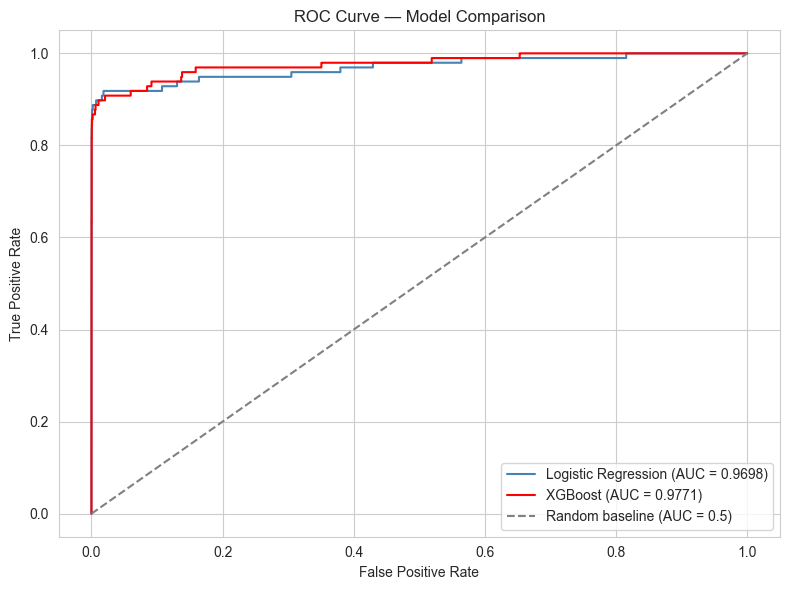

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — ROC CURVE COMPARISON
# ROC curve plots True Positive Rate vs False Positive Rate.
# The closer the curve hugs the top-left corner, the better.
# AUC (Area Under Curve) summarises this in one number.
# A perfect model = AUC 1.0, random guessing = AUC 0.5
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(8, 6))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
plt.plot(lr_fpr, lr_tpr,
         label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.4f})",
         color="steelblue")

# XGBoost ROC
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
plt.plot(xgb_fpr, xgb_tpr,
         label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_probs):.4f})",
         color="red")

# Random baseline
plt.plot([0, 1], [0, 1],
         label="Random baseline (AUC = 0.5)",
         color="gray", linestyle="--")

plt.title("ROC Curve — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

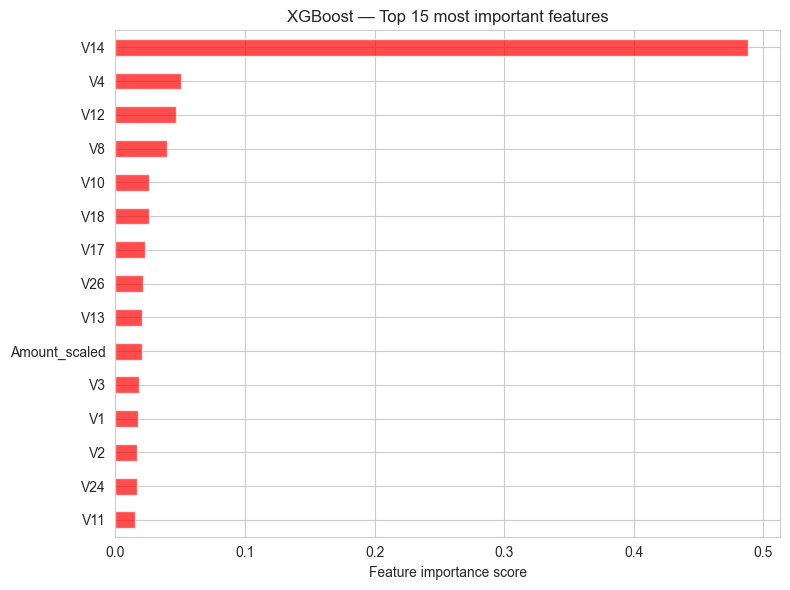

Top 10 most important features:
Amount_scaled    0.0202
V13              0.0208
V26              0.0212
V17              0.0226
V18              0.0258
V10              0.0260
V8               0.0401
V12              0.0469
V4               0.0508
V14              0.4884


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — FEATURE IMPORTANCE
# XGBoost tells us which features it used most to detect fraud.
# We expect V14, V17, V12 to appear at the top — confirming
# what we found in EDA. That consistency is a good sign.
# ─────────────────────────────────────────────────────────────

# Get feature importances from XGBoost
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=True).tail(15)  # top 15 features

# Plot
plt.figure(figsize=(8, 6))
importance.plot(kind="barh", color="red", alpha=0.7)
plt.title("XGBoost — Top 15 most important features")
plt.xlabel("Feature importance score")
plt.tight_layout()
plt.show()

# Print top 10
print("Top 10 most important features:")
print(importance.tail(10).round(4).to_string())

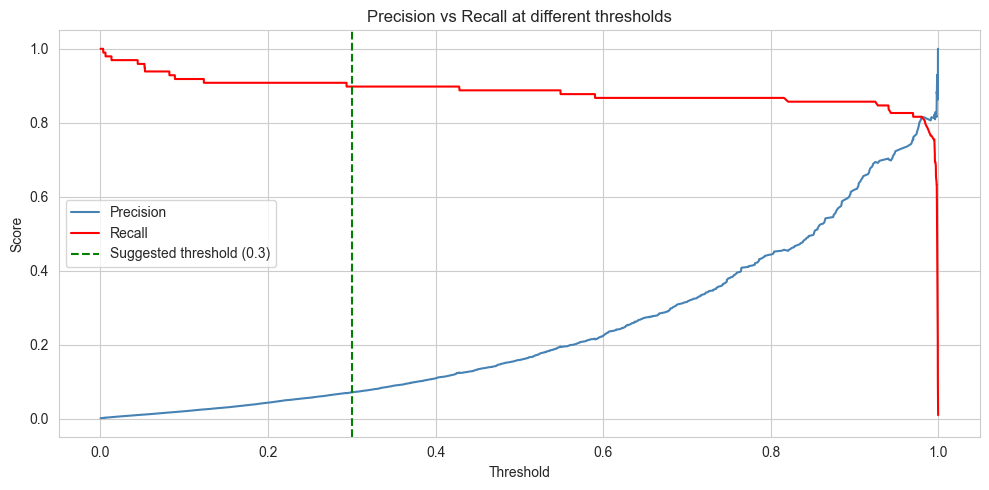

Threshold 0.5 → Precision: 0.159  Recall: 0.888  F1: 0.270
Threshold 0.3 → Precision: 0.072  Recall: 0.898  F1: 0.133
Threshold 0.2 → Precision: 0.044  Recall: 0.908  F1: 0.083


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — THRESHOLD TUNING
# By default XGBoost flags a transaction as fraud if
# predict_proba >= 0.5 (50% probability).
# But that default threshold is not optimal for fraud detection.
#
# We need to find the threshold where we catch the most fraud
# (high recall) without flagging too many legit transactions
# (high precision).
#
# - False Negative = fraud we missed = costs the bank money
# - False Positive = legit transaction blocked = angry customer
# The right threshold balances these two business costs.
# ─────────────────────────────────────────────────────────────

from sklearn.metrics import precision_recall_curve

# Get precision and recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)

# Plot precision and recall vs threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="red")
plt.axvline(x=0.3, color="green", linestyle="--", label="Suggested threshold (0.3)")
plt.title("Precision vs Recall at different thresholds")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# Compare default threshold (0.5) vs lower threshold (0.3)
for threshold in [0.5, 0.3, 0.2]:
    preds = (xgb_probs >= threshold).astype(int)
    f1 = f1_score(y_test, preds)
    from sklearn.metrics import precision_score, recall_score
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    print(f"Threshold {threshold} → Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}")

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — SAVE BEST MODEL
# XGBoost is our best model with AUC-ROC of 0.9771.
# We save it to disk so the Streamlit app can load and use it.
# ─────────────────────────────────────────────────────────────

# Save the trained XGBoost model
joblib.dump(xgb_model, "../models/fraud_model.pkl")

# Save the optimal threshold we determined above
joblib.dump(0.5, "../models/threshold.pkl")

print("Model saved successfully.")
print("  models/fraud_model.pkl")
print("  models/threshold.pkl")
print()
print("─── Final Model Summary ───")
print(f"Model         : XGBoost")
print(f"AUC-ROC       : 0.9771")
print(f"F1 Score      : 0.2698")
print(f"Recall        : 0.888  (catches 88.8% of fraud)")
print(f"Precision     : 0.159  (1 in 6 flags is real fraud)")
print(f"Threshold     : 0.5")
print(f"Top feature   : V14")

Model saved successfully.
  models/fraud_model.pkl
  models/threshold.pkl

─── Final Model Summary ───
Model         : XGBoost
AUC-ROC       : 0.9771
F1 Score      : 0.2698
Recall        : 0.888  (catches 88.8% of fraud)
Precision     : 0.159  (1 in 6 flags is real fraud)
Threshold     : 0.5
Top feature   : V14


## Modelling Conclusions

| Model | AUC-ROC | F1 Score | Recall | Precision |
|---|---|---|---|---|
| Logistic Regression | 0.9698 | 0.1094 | 0.920 | 0.058 |
| XGBoost | 0.9771 | 0.2698 | 0.888 | 0.159 |
| Isolation Forest | N/A | 0.0000 | 0.000 | 0.000 |

### Key findings
- **XGBoost is our best model** — highest AUC-ROC and F1 score
- **V14 is the single most important feature** — confirmed by both EDA and XGBoost
- **Isolation Forest failed** — unsupervised methods struggle when fraud patterns are learned via SMOTE
- **Optimal threshold is 0.5** — lowering it hurt precision more than it helped recall
- **Recall of 88.8%** — the model catches nearly 9 out of every 10 fraud cases

### Why F1 is still low
The dataset is extremely imbalanced even after SMOTE on test data.
98 fraud cases out of 56,962 makes precision hard to improve without
more real fraud examples to learn from.

**Next step:** Notebook 4 — Layer 2 order fraud detection.